Importing all packages needed: pandas, matplotlib, seaborn and sqlite.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#reading dataset bird_strikes.csv to pandas as df
df = pd.read_csv('bird_strikes.csv', keep_default_na=False) #arg so "None" would not be null value

df.info()  #displaying basic info on dataframe df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25429 entries, 0 to 25428
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   RecordID                  25429 non-null  int64 
 1   AircraftType              25429 non-null  object
 2   AirportName               25429 non-null  object
 3   AltitudeBin               25429 non-null  object
 4   MakeModel                 25429 non-null  object
 5   NumberStruck              25429 non-null  object
 6   NumberStruckActual        25429 non-null  int64 
 7   Effect                    25429 non-null  object
 8   FlightDate                25429 non-null  object
 9   Damage                    25429 non-null  object
 10  Engines                   25429 non-null  object
 11  Operator                  25429 non-null  object
 12  OriginState               25429 non-null  object
 13  FlightPhase               25429 non-null  object
 14  ConditionsPrecipitatio

In [3]:
#dropping columns in df
df.drop(columns=[
    'AircraftType', 'AltitudeBin', 'NumberStruck',
    'NumberStruckActual', 'Engines', 'RemainsSentToSmithsonian',
    'RemainsCollected?', 'WildlifeSize', 'PilotWarned',
    'IsAircraftLarge?'], axis=1, inplace=True)
df.columns #listing columns to confirm if drop was succesful

Index(['RecordID', 'AirportName', 'MakeModel', 'Effect', 'FlightDate',
       'Damage', 'Operator', 'OriginState', 'FlightPhase',
       'ConditionsPrecipitation', 'Remarks', 'ConditionsSky',
       'WildlifeSpecies', 'Cost', 'Altitude', 'PeopleInjured'],
      dtype='object')

In [4]:
#renaming columns in df
df.rename(columns={
    'AirportName': 'Airport',
    'Operator': 'Airline',
    'OriginState': 'State',
    'ConditionsPrecipitation': 'Precipitation',
    'ConditionsSky': 'Clouds',
    'WildlifeSpecies': 'BirdSpecies'}, inplace=True) 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25429 entries, 0 to 25428
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   RecordID       25429 non-null  int64 
 1   Airport        25429 non-null  object
 2   MakeModel      25429 non-null  object
 3   Effect         25429 non-null  object
 4   FlightDate     25429 non-null  object
 5   Damage         25429 non-null  object
 6   Airline        25429 non-null  object
 7   State          25429 non-null  object
 8   FlightPhase    25429 non-null  object
 9   Precipitation  25429 non-null  object
 10  Remarks        25429 non-null  object
 11  Clouds         25429 non-null  object
 12  BirdSpecies    25429 non-null  object
 13  Cost           25429 non-null  object
 14  Altitude       25429 non-null  int64 
 15  PeopleInjured  25429 non-null  int64 
dtypes: int64(3), object(13)
memory usage: 3.1+ MB


In [5]:
df.isnull().sum() #checking for null values in df

RecordID         0
Airport          0
MakeModel        0
Effect           0
FlightDate       0
Damage           0
Airline          0
State            0
FlightPhase      0
Precipitation    0
Remarks          0
Clouds           0
BirdSpecies      0
Cost             0
Altitude         0
PeopleInjured    0
dtype: int64

In [6]:
df.head()

,RecordID,Airport,MakeModel,Effect,FlightDate,Damage,Airline,State,FlightPhase,Precipitation,Remarks,Clouds,BirdSpecies,Cost,Altitude,PeopleInjured
0,202152,LAGUARDIA NY,B-737-400,Engine Shut Down,11/23/2019 0:00,Caused damage,US AIRWAYS*,New York,Climb,None,FLT 753. PILOT REPTD A HUNDRED BIRDS ON UNKN T...,No Cloud,Unknown bird - medium,"30,736",1500,0
1,208159,DALLAS/FORT WORTH INTL ARPT,MD-80,None,7/25/2019 0:00,Caused damage,AMERICAN AIRLINES,Texas,Landing Roll,None,102 CARCASSES FOUND. 1 LDG LIGHT ON NOSE GEAR ...,Some Cloud,Rock pigeon,0,0,0
2,207601,LAKEFRONT AIRPORT,C-500,None,9/14/2019 0:00,No damage,BUSINESS,Louisiana,Approach,None,FLEW UNDER A VERY LARGE FLOCK OF BIRDS OVER AP...,No Cloud,European starling,0,50,0
3,215953,SEATTLE-TACOMA INTL,B-737-400,Precautionary Landing,9/5/2019 0:00,No damage,ALASKA AIRLINES,Washington,Climb,None,"NOTAM WARNING. 26 BIRDS HIT THE A/C, FORCING A...",Some Cloud,European starling,0,50,0
4,219878,NORFOLK INTL,CL-RJ100/200,None,6/23/2020 0:00,No damage,COMAIR AIRLINES,Virginia,Approach,None,NO DMG REPTD.,No Cloud,European starling,0,50,0


In [7]:
#reading in the second dataset airport.csv to pandas
df2 = pd.read_csv('airport.csv')

df2.info()  #displaying basic info on dataframe df2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7698 entries, 0 to 7697
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               7698 non-null   int64  
 1   name             7698 non-null   object 
 2   city             7649 non-null   object 
 3   country          7698 non-null   object 
 4   iata             7698 non-null   object 
 5   icao             7698 non-null   object 
 6   latitude         7698 non-null   float64
 7   longitude        7698 non-null   float64
 8   altitude         7698 non-null   int64  
 9   timezone_offset  7698 non-null   object 
 10  dst              7698 non-null   object 
 11  timezone         7698 non-null   object 
 12  type             7698 non-null   object 
 13  source           0 non-null      float64
dtypes: float64(3), int64(2), object(9)
memory usage: 842.1+ KB


In [8]:
#dropping columns in df2
df2 = df2.drop(columns=['id', 'timezone_offset', 'icao', 'dst', 'timezone', 'type', 'source','altitude'])
df2.columns #listing columns to confirm if drop was succesful

Index(['name', 'city', 'country', 'iata', 'latitude', 'longitude'], dtype='object')

In [9]:
#renaming 'name' column in df2 to 'airport'
df2.rename(columns={
    'name': 'airport'
    }, inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7698 entries, 0 to 7697
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   airport    7698 non-null   object 
 1   city       7649 non-null   object 
 2   country    7698 non-null   object 
 3   iata       7698 non-null   object 
 4   latitude   7698 non-null   float64
 5   longitude  7698 non-null   float64
dtypes: float64(2), object(4)
memory usage: 361.0+ KB


In [10]:
df2.isnull().sum() #checking for null values in df2

airport       0
city         49
country       0
iata          0
latitude      0
longitude     0
dtype: int64

In [11]:
df2.head()

,airport,city,country,iata,latitude,longitude
0,Goroka Airport,Goroka,Papua New Guinea,GKA,-6.081690,145.391998
1,Madang Airport,Madang,Papua New Guinea,MAG,-5.207080,145.789001
2,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,-5.826790,144.296005
3,Nadzab Airport,Nadzab,Papua New Guinea,LAE,-6.569803,146.725977
4,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,-9.443380,147.220001


This function: values() is designed to list any value counts of columns in the df you wish to display. By default it will list all data "limit=None" unless you pass in the arg ".head(limit)" the number of records you wish to display. For example: values(df, 'column_name', 8) would display the top 8 most frequent values in df and the column you choose. See example below.

In [12]:
def values(df, column_name, limit=None):
    counts = df[column_name].value_counts()
    if limit is not None:
        print(counts.head(limit))
    else:
        print(counts)

In [13]:
values(df, 'MakeModel', 8)

MakeModel
B-737-700       2488
B-737-300       2309
CL-RJ100/200    1951
A-320           1193
A-319           1000
B-757-200        992
EMB-145          990
B-737-800        678
Name: count, dtype: int64


In [14]:
#converting 'FlightDate' to datetime object
df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors='coerce')
df['FlightDate'] = df['FlightDate'].dt.strftime('%#m/%d/%Y') #formats datetime object to MM/DD/YYYY

In [15]:
df['FlightDate'].head()

0    11/23/2019
1     7/25/2019
2     9/14/2019
3     9/05/2019
4     6/23/2020
Name: FlightDate, dtype: object

In [16]:
#removing non-numeric characters such as "$", ",", etc...
df['Cost'] = df['Cost'].str.replace(r'[^\d.]', '', regex=True)

#converting 'Cost' column to numeric Int64
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce').astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25429 entries, 0 to 25428
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   RecordID       25429 non-null  int64 
 1   Airport        25429 non-null  object
 2   MakeModel      25429 non-null  object
 3   Effect         25429 non-null  object
 4   FlightDate     25423 non-null  object
 5   Damage         25429 non-null  object
 6   Airline        25429 non-null  object
 7   State          25429 non-null  object
 8   FlightPhase    25429 non-null  object
 9   Precipitation  25429 non-null  object
 10  Remarks        25429 non-null  object
 11  Clouds         25429 non-null  object
 12  BirdSpecies    25429 non-null  object
 13  Cost           25429 non-null  Int64 
 14  Altitude       25429 non-null  int64 
 15  PeopleInjured  25429 non-null  int64 
dtypes: Int64(1), int64(3), object(12)
memory usage: 3.1+ MB


This fuction: claim() is designed to create a new column in the df dataframe called 'InsuranceClaim'. It does this by going thru each row in the dataframe and checking the value in the 'Cost' column. If the value is 250000 or more it returns 'Claim' if not it returns 'No Claim' in the newly created column.

In [17]:
def claim(row: pd.Series) -> str: #type hinting to string
    if row['Cost'] >= 250000:
        return 'Claim'
    else:
        return 'No Claim'

df['InsuranceClaim'] = df.apply(claim, axis=1) #axis=1 applying function row-wise

In [18]:
df.columns #checking for new column 'InsuranceClaim'

Index(['RecordID', 'Airport', 'MakeModel', 'Effect', 'FlightDate', 'Damage',
       'Airline', 'State', 'FlightPhase', 'Precipitation', 'Remarks', 'Clouds',
       'BirdSpecies', 'Cost', 'Altitude', 'PeopleInjured', 'InsuranceClaim'],
      dtype='object')

In [19]:
values(df, 'InsuranceClaim')

InsuranceClaim
No Claim    25334
Claim          95
Name: count, dtype: int64


This function: filter_value() allows you to retrieve filtered rows based on what value you specify of the column you choose with the option of limiting how many records to return. For example: filter_value(df, 'InsuranceClaim', 'Claim', 4) would display four records from df 'InsuranceClaim' column that contains the str value of 'Claim'.

In [20]:
# Original function before modifying limits
# def filter_value(df: pd.DataFrame, column: str, value: str) -> pd.DataFrame:
#     return df[df[column] == value]

#Returns filtered DataFrame where specified column matches given string value
def filter_value(df: pd.DataFrame, column: str, value: str, limit: int = None) -> pd.DataFrame:
    filtered_df = df[df[column] == value]
    if limit is not None:
        return filtered_df.head(limit)
    else:
        return filtered_df

    """
    Parameters:
    df (pd.DataFrame): The input DataFrame
    column (str): name of the column to filter on
    value (str): string value to match
    limit (int): limit number of rows displayed """

    

In [45]:
filter_value(df, 'InsuranceClaim', 'Claim', 4)

,RecordID,Airport,MakeModel,Effect,FlightDate,Damage,Airline,State,FlightPhase,Precipitation,Remarks,Clouds,BirdSpecies,Cost,Altitude,PeopleInjured,InsuranceClaim
6,221697,NEW CASTLE COUNTY,LEARJET-25,Other,8/17/2020,Caused damage,BUSINESS,Delaware,Climb,None,,No Cloud,European starling,1481711,150,0,Claim
7,236635,WASHINGTON DULLES INTL ARPT,A-320,Other,3/01/2020,Caused damage,UNITED AIRLINES,DC,Approach,None,WS ASSISTED IN CLEAN-UP OF 273 STARLINGS AND 1...,Some Cloud,European starling,1483141,100,0,Claim
60,202483,LOS ANGELES INTL,SAAB-340,Aborted Take-off,5/15/2019,Caused damage,AMERICAN EAGLE AIRLINES,California,Take-off run,None,"FLT 103. BIRD STRUCK NOSE CONE, BLOOD OVER WIN...",Some Cloud,Rock pigeon,801820,0,0,Claim
220,4964,BARKSDALE AIR FORCE BASE ARPT,B-52H,Precautionary Landing,12/12/2019,Caused damage,MILITARY,Louisiana,Climb,None,Post flight borescope of the #2 engine reveale...,No Cloud,Gadwall,458207,500,0,Claim


In [21]:
#Listing top 10 values in 'Cost' column
df['Cost'].sort_values(ascending=False).head(10)

232      12397751
4501      5704387
13796     5704387
23407     4570000
291       3644483
17499     3463326
3828      3228053
1089      3006592
21849     2977459
3225      2846160
Name: Cost, dtype: Int64

This function: list() is designed to list any row of data you wish to view in df based on it's index location which starts at 0 in the dataset. For example if you wish to view row #232 type list(232). See example below func.

In [22]:
def list(index):
    print(df.iloc[index]) #indexer used to access row by integer position

In [23]:
list(232)

RecordID                                                     209401
Airport                                         TROY MUNICIPAL ARPT
MakeModel                                                LEARJET-60
Effect                                                        Other
FlightDate                                                1/14/2019
Damage                                                Caused damage
Airline                                                    BUSINESS
State                                                       Alabama
FlightPhase                                            Landing Roll
Precipitation                                                  None
Remarks           HIT 2 DEER AND RAN OFF RWY. THRUST REVERSERS W...
Clouds                                                     No Cloud
BirdSpecies                                       White-tailed deer
Cost                                                       12397751
Altitude                                        

In [24]:
#displaying sum of rows that have WT deer in 'BirdSpecies' column
df['BirdSpecies'].str.lower().eq('white-tailed deer').sum()

np.int64(85)

In [25]:
#searching 'BirdSpecies' column in df for any records 'White-tailed'
df['BirdSpecies'].str.contains('White-tailed', case=False).sum()
#assigning "deer" to any records that contain 'White-tailed'
deer = df[df['BirdSpecies'].str.contains('White-tailed', case=False, na=False)]
print(deer)

       RecordID                           Airport       MakeModel  \
232      209401               TROY MUNICIPAL ARPT      LEARJET-60   
750      215288                   SLIDELL AIRPORT    C-441 CONQUE   
1404     231472  FULTON COUNTY ARPT - BROWN FIELD      HAWKER 800   
2830     263557       JESSE VIERTEL MEMORIAL ARPT           BE-35   
3366     300321       OCONEE COUNTY REGIONAL ARPT    PA-46 MALIBU   
...         ...                               ...             ...   
23189    310277          STILLWATER REGIONAL ARPT  A-23 MUSKATEER   
23248    310296           SAN FRANCISCO INTL ARPT           A-319   
24045    313532                    BOB SIKES ARPT    BE-58  BARON   
24112    313586            BOLIVAR MUNICIPAL ARPT           PA-32   
24276    314585                 EAST HAMPTON ARPT           C-340   

                 Effect  FlightDate         Damage          Airline  \
232               Other   1/14/2019  Caused damage         BUSINESS   
750    Engine Shut Down  11/2

In [26]:
excluded_deer = ['white-tailed deer']
df = df[~df['BirdSpecies'].str.lower().isin([s.lower() for s in excluded_deer])]
# ~ Logical NOT operator.
# str.lower() - converts to lower for case-insensitive comparison
# [s.lower() for s in excluded_deer] - converts all in excluded_deer to lowercase

In [27]:
#Confirming sum of rows that have WT deer in 'BirdSpecies' column is 0
df['BirdSpecies'].str.lower().eq('white-tailed deer').sum()

np.int64(0)

In [28]:
#establishing connection to SQLite database 'bird.strikes.db'
conn = sqlite3.connect('bird_strikes.db')

In [29]:
#inserting dataframe df and df2 into SQLite via conn
df.to_sql('bird_strikes', conn, if_exists='replace', index=False)
df2.to_sql('airports', conn, if_exists='replace', index=False)

7698

In [30]:
#listing tables in the connected database
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall()) #prints out results fetched from query

[('bird_strikes',), ('airports',)]


In [31]:
#quering database and fetching first five records from bird_strikes
cursor.execute("SELECT * FROM bird_strikes LIMIT 5;")
print(cursor.fetchall())

[(202152, 'LAGUARDIA NY', 'B-737-400', 'Engine Shut Down', '11/23/2019', 'Caused damage', 'US AIRWAYS*', 'New York', 'Climb', 'None', 'FLT 753. PILOT REPTD A HUNDRED BIRDS ON UNKN TYPE. #1 ENG WAS SHUT DOWN AND DIVERTED TO EWR. SLIGHT VIBRATION. A/C WAS OUT OF SVC FOR REPAIRS TO COWLING, FAN DUCT ACCOUSTIC PANEL. INGESTION. DENTED FAN BLADE #26 IN #1 ENG. HEAVY BLOOD STAINS ON L WINGTIP', 'No Cloud', 'Unknown bird - medium', 30736, 1500, 0, 'No Claim'), (208159, 'DALLAS/FORT WORTH INTL ARPT', 'MD-80', 'None', '7/25/2019', 'Caused damage', 'AMERICAN AIRLINES', 'Texas', 'Landing Roll', 'None', '102 CARCASSES FOUND. 1 LDG LIGHT ON NOSE GEAR WAS DAMAGED AND REPLACED.', 'Some Cloud', 'Rock pigeon', 0, 0, 0, 'No Claim'), (207601, 'LAKEFRONT AIRPORT', 'C-500', 'None', '9/14/2019', 'No damage', 'BUSINESS', 'Louisiana', 'Approach', 'None', 'FLEW UNDER A VERY LARGE FLOCK OF BIRDS OVER APCH END OF RWY. NO DMG. JUST A LOT OF BIRD DROPPINGS ON WINDSCREEN.', 'No Cloud', 'European starling', 0, 50, 0

In [32]:
#inspecting the schema of bird_strikes table
cursor.execute("PRAGMA table_info(bird_strikes);")
print(cursor.fetchall())

[(0, 'RecordID', 'INTEGER', 0, None, 0), (1, 'Airport', 'TEXT', 0, None, 0), (2, 'MakeModel', 'TEXT', 0, None, 0), (3, 'Effect', 'TEXT', 0, None, 0), (4, 'FlightDate', 'TEXT', 0, None, 0), (5, 'Damage', 'TEXT', 0, None, 0), (6, 'Airline', 'TEXT', 0, None, 0), (7, 'State', 'TEXT', 0, None, 0), (8, 'FlightPhase', 'TEXT', 0, None, 0), (9, 'Precipitation', 'TEXT', 0, None, 0), (10, 'Remarks', 'TEXT', 0, None, 0), (11, 'Clouds', 'TEXT', 0, None, 0), (12, 'BirdSpecies', 'TEXT', 0, None, 0), (13, 'Cost', 'INTEGER', 0, None, 0), (14, 'Altitude', 'INTEGER', 0, None, 0), (15, 'PeopleInjured', 'INTEGER', 0, None, 0), (16, 'InsuranceClaim', 'TEXT', 0, None, 0)]


In [33]:
#quering database and fetching first five records from airports
cursor.execute("SELECT * FROM airports LIMIT 5;")
print(cursor.fetchall())

[('Goroka Airport', 'Goroka', 'Papua New Guinea', 'GKA', -6.081689834590001, 145.391998291), ('Madang Airport', 'Madang', 'Papua New Guinea', 'MAG', -5.20707988739, 145.789001465), ('Mount Hagen Kagamuga Airport', 'Mount Hagen', 'Papua New Guinea', 'HGU', -5.826789855957031, 144.29600524902344), ('Nadzab Airport', 'Nadzab', 'Papua New Guinea', 'LAE', -6.569803, 146.725977), ('Port Moresby Jacksons International Airport', 'Port Moresby', 'Papua New Guinea', 'POM', -9.44338035583496, 147.22000122070312)]


In [34]:
#inspecting the schema of airports table
cursor.execute("PRAGMA table_info(airports);")
print(cursor.fetchall())

[(0, 'airport', 'TEXT', 0, None, 0), (1, 'city', 'TEXT', 0, None, 0), (2, 'country', 'TEXT', 0, None, 0), (3, 'iata', 'TEXT', 0, None, 0), (4, 'latitude', 'REAL', 0, None, 0), (5, 'longitude', 'REAL', 0, None, 0)]


In [35]:
# cleaning and making airport names standard in both tables
df['Airport'] = df['Airport'].str.strip().str.upper()
df2['airport'] = df2['airport'].str.strip().str.upper()
# str.strip() removes leading and trailing whitespaces
# str.upper() converts names to uppercase

In [36]:
#quering database and fetching top 10 airports with most bird strikes
cursor.execute("""
    SELECT airport, COUNT(*) as strike_count
    FROM bird_strikes
    GROUP BY airport
    ORDER BY strike_count DESC
    LIMIT 10;
""")
print(cursor.fetchall())

[('DALLAS/FORT WORTH INTL ARPT', 803), ('SACRAMENTO INTL', 676), ('SALT LAKE CITY INTL', 479), ('DENVER INTL AIRPORT', 476), ('KANSAS CITY INTL', 452), ('PHILADELPHIA INTL', 442), ('ORLANDO INTL', 408), ('BALTIMORE WASH INTL', 401), ('LOUISVILLE INTL ARPT', 395), ('JOHN F KENNEDY INTL', 390)]


In [37]:
airport_join = """
SELECT *
FROM bird_strikes AS b
LEFT JOIN airports AS a
ON b.airport = a.airport
"""
airportQ = pd.read_sql_query(airport_join, conn)

In [38]:
#checking columns of airportQ
print(airportQ.columns)

Index(['RecordID', 'Airport', 'MakeModel', 'Effect', 'FlightDate', 'Damage',
       'Airline', 'State', 'FlightPhase', 'Precipitation', 'Remarks', 'Clouds',
       'BirdSpecies', 'Cost', 'Altitude', 'PeopleInjured', 'InsuranceClaim',
       'airport', 'city', 'country', 'iata', 'latitude', 'longitude'],
      dtype='object')


In [39]:
values(df, 'Airline', 6)

Airline
SOUTHWEST AIRLINES         4628
BUSINESS                   3017
AMERICAN AIRLINES          2058
DELTA AIR LINES            1349
AMERICAN EAGLE AIRLINES     932
SKYWEST AIRLINES            891
Name: count, dtype: int64


Text(0, 0.5, '')

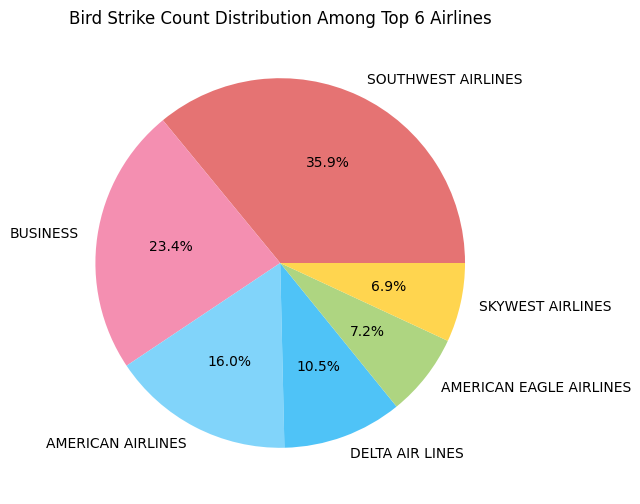

In [40]:
#Top 6 airlines from the joined table
top_airlines = (
    airportQ['Airline']
    .value_counts()
    .head(6)
)

#customized colors
colors = ['#E57373', '#F48FB1', '#81D4FA', '#4FC3F7', '#AED581', '#FFD54F']

top_airlines.plot(
    kind="pie",
    autopct='%1.1f%%', #automatic percentage '%1.1f%%' how % will be displayed 
    figsize=(6, 6), #sets fig dimentions in inches
    colors=colors,
    title='Bird Strike Count Distribution Among Top 6 Airlines'
)

plt.ylabel('')


In [41]:
values(df, 'FlightPhase')

FlightPhase
Approach        10377
Landing Roll     4986
Take-off run     4696
Climb            4425
Descent           776
Taxi               74
Parked             10
Name: count, dtype: int64


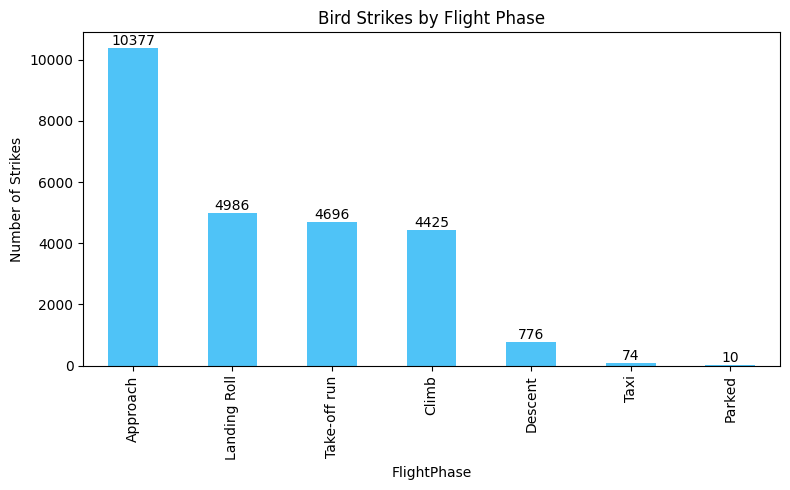

In [42]:
# assigning value counts of 'FlightPhase' column to flight_phase_counts var
flight_phase_counts = airportQ['FlightPhase'].value_counts()

# plotting bird strike counts by flight phase
ax = flight_phase_counts.plot(
    kind="bar",
    color='#4FC3F7',
    figsize=(8, 5),
    title='Bird Strikes by Flight Phase'
)


plt.ylabel('Number of Strikes')

# count labels on top of each bar
for i, count in enumerate(flight_phase_counts): # loop through each bar
    ax.text(i, count, str(count), ha='center', va='bottom') # adds text to the plot
    # str(count) - converts # to str to display
    # ha='center' - centering over bar
    # va='bottom' - vertically align above bar 


plt.tight_layout() # makes it look good - auto features
plt.show()


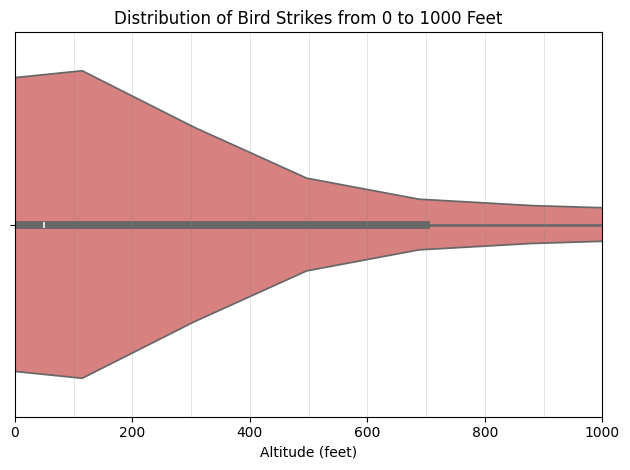

In [43]:
# using seaborn to create violin plot of the 'Altitude' column from airportQ DataFrame

sns.violinplot(x=airportQ['Altitude'], color='#E57373')

x_positions = range(100, 1000, 100) # (start value, ending boundary, step size) 

for val in x_positions:
    plt.axvline(x=val, ymin=0, ymax=1, color='gray', alpha=0.3, linewidth=0.5)


#x-axis limit
plt.xlim(0, 1000)

plt.title("Distribution of Bird Strikes from 0 to 1000 Feet")
plt.xlabel("Altitude (feet)")
plt.tight_layout()
plt.show()

In [44]:
conn.close() #closing database connection